<a href="https://colab.research.google.com/github/Ankur-3012/Placement/blob/main/Tredence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Starting experiment with lambda = 0.0001 ---
Using device: cpu
Epoch 1/5 - Loss: 15.6309 - Time: 30.78s
Epoch 2/5 - Loss: 2.1842 - Time: 30.15s
Epoch 3/5 - Loss: 1.9999 - Time: 31.74s
Epoch 4/5 - Loss: 1.9288 - Time: 31.35s
Epoch 5/5 - Loss: 1.8862 - Time: 30.95s
Test Accuracy: 35.33%
Sparsity Level: 99.96%

--- Starting experiment with lambda = 0.001 ---
Using device: cpu
Epoch 1/5 - Loss: 135.8600 - Time: 30.32s
Epoch 2/5 - Loss: 4.3634 - Time: 30.60s
Epoch 3/5 - Loss: 3.1765 - Time: 30.88s
Epoch 4/5 - Loss: 2.7932 - Time: 31.58s
Epoch 5/5 - Loss: 2.6154 - Time: 30.91s
Test Accuracy: 10.00%
Sparsity Level: 100.00%

--- Starting experiment with lambda = 0.01 ---
Using device: cpu
Epoch 1/5 - Loss: 1337.7013 - Time: 30.73s
Epoch 2/5 - Loss: 22.9085 - Time: 30.22s
Epoch 3/5 - Loss: 11.0402 - Time: 33.82s
Epoch 4/5 - Loss: 7.2066 - Time: 31.88s
Epoch 5/5 - Loss: 5.4292 - Time: 33.85s
Test Accuracy: 10.00%
Sparsity Level: 100.00%

--- Final Results ---
Lambda     | Test Accuracy (%) 

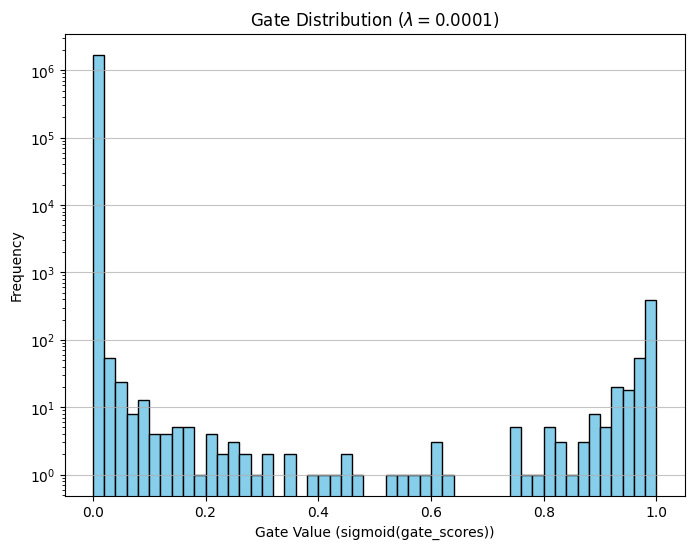

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os
import time
import math


class PrunableLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features


        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))


        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))


        self.reset_parameters()

    def reset_parameters(self):

        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)


        nn.init.constant_(self.gate_scores, 3.0)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)

        pruned_weights = self.weight * gates

        return F.linear(x, pruned_weights, self.bias)
class SelfPruningMLP(nn.Module):
    def __init__(self):
        super(SelfPruningMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_sparsity_loss(self):

        sparsity_loss = 0.0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores)
                sparsity_loss += torch.sum(gates)
        return sparsity_loss

    def get_sparsity_level(self):

        total_weights = 0
        pruned_weights = 0
        with torch.no_grad():
            for module in self.modules():
                if isinstance(module, PrunableLinear):
                    gates = torch.sigmoid(module.gate_scores)
                    total_weights += gates.numel()
                    pruned_weights += torch.sum(gates < 1e-2).item()

        return (pruned_weights / total_weights) * 100.0 if total_weights > 0 else 0.0

    def get_all_gates(self):

        all_gates = []
        with torch.no_grad():
            for module in self.modules():
                if isinstance(module, PrunableLinear):
                    gates = torch.sigmoid(module.gate_scores)
                    all_gates.append(gates.view(-1))
        return torch.cat(all_gates)


def train_and_evaluate(lambda_reg: float, epochs: int = 5):
    print(f"\n--- Starting experiment with lambda = {lambda_reg} ---")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")


    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])


    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)


    model = SelfPruningMLP().to(device)
    criterion = nn.CrossEntropyLoss()


    gate_params = []
    other_params = []
    for name, param in model.named_parameters():
        if 'gate_scores' in name:
            gate_params.append(param)
        else:
            other_params.append(param)

    optimizer = optim.Adam([
        {'params': other_params, 'lr': 0.001},
        {'params': gate_params, 'lr': 0.1}
    ])

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()

        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            ce_loss = criterion(outputs, labels)
            sparsity_loss = model.get_sparsity_loss()

            loss = ce_loss + lambda_reg * sparsity_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(trainloader):.4f} - Time: {epoch_time:.2f}s")

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    sparsity = model.get_sparsity_level()

    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Sparsity Level: {sparsity:.2f}%")

    return accuracy, sparsity, model.get_all_gates().cpu().numpy()

def main():
    lambdas = [1e-4, 1e-3, 1e-2]
    results = {}
    best_lambda = None
    best_tradeoff_score = -float('inf')
    best_gates = None

    epochs = 5

    for l in lambdas:
        acc, spar, gates = train_and_evaluate(l, epochs=epochs)
        results[l] = {'accuracy': acc, 'sparsity': spar}

        tradeoff = acc + spar * 0.5
        if tradeoff > best_tradeoff_score:
            best_tradeoff_score = tradeoff
            best_lambda = l
            best_gates = gates

    print("\n--- Final Results ---")
    print(f"{'Lambda':<10} | {'Test Accuracy (%)':<20} | {'Sparsity Level (%)':<20}")
    print("-" * 55)
    for l in lambdas:
        print(f"{l:<10} | {results[l]['accuracy']:<20.2f} | {results[l]['sparsity']:<20.2f}")


    print(f"\nSaving gate distribution plot for best lambda ({best_lambda})...")
    plt.figure(figsize=(8, 6))
    plt.hist(best_gates, bins=50, color='skyblue', edgecolor='black')
    plt.title(fr'Gate Distribution ($\lambda={best_lambda}$)')
    plt.xlabel('Gate Value (sigmoid(gate_scores))')
    plt.ylabel('Frequency')
    plt.yscale('log')
    plt.grid(axis='y', alpha=0.75)


    os.makedirs('artifacts', exist_ok=True)
    plt.savefig('artifacts/gate_distribution.png')
    plt.savefig('gate_distribution.png')
    print("Plot saved to gate_distribution.png.")

if __name__ == '__main__':
    main()
